In [1]:
#General imports
resol = 300
import matplotlib.pyplot as plt
import pandas as pd

plt.rcParams.update({
    "text.usetex": True,
    "font.family": "serif",
    "axes.linewidth": 0.7,
    "xtick.major.width": 0.6,
    "ytick.major.width": 0.6,
})

import sys
import numpy as np
from pathlib import Path
pi = np.pi

project_root = Path().resolve().parents[0]
sys.path.append(str(project_root))

#Local imports
from src.bare_param import get_bare_param_n1, get_bare_param_n2, get_bare_param_n

<h1> Fix problem parameters </h1>

In [10]:
#atom and waveguide
omega_A = 10*pi
Gamma = 5*pi

ir = 2*pi
uv = 17*pi

In [11]:
omega_0_n1, gamma_n1 = get_bare_param_n1(omega_A, Gamma, ir, uv)

omega_0_n2, gamma_n2 = get_bare_param_n2(omega_A, Gamma, ir, uv)

omega_0_n, gamma_n = get_bare_param_n(omega_A, Gamma, ir, uv, n=2)

print(f"omega_A = {omega_A:.5f}, Gamma = {Gamma:.5f} \n --------------")
print(f"omega_0_n1 = {omega_0_n1:.5f}, gamma_n1 = {gamma_n1:.5f} \n --------------")
print(f"omega_0_n2 = {omega_0_n2:.5f}, gamma_n2 = {gamma_n2:.5f} \n --------------")
print(f"omega_0_n = {omega_0_n:.5f}, gamma_n = {gamma_n:.5f} \n --------------")

omega_A = 31.41593, Gamma = 15.70796 
 --------------
omega_0_n1 = 31.14069, gamma_n1 = 12.95128 
 --------------
omega_0_n2 = 31.16660, gamma_n2 = 12.94830 
 --------------
omega_0_n = 31.16660, gamma_n = 12.94830 
 --------------


<h1> Convergence ? </h1>

In [57]:
n_tab = np.arange(1,100)
omega_0_n_tab = []
gamma_n_tab = []

for n in n_tab:
    omega_0_n, gamma_n = get_bare_param_n(omega_A, Gamma, ir, uv, n=n)
    omega_0_n_tab.append(omega_0_n)
    gamma_n_tab.append(gamma_n)

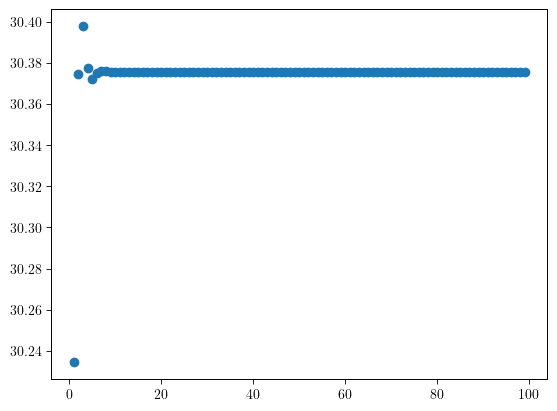

In [58]:
plt.scatter(n_tab, omega_0_n_tab)
#plt.ylim([ir, uv])
plt.show()

<h1> Plot the parameters </h1>

In [ ]:
nb_pts = 20

omega_ref = 8*pi

ir_tab = omega_ref - np.linspace(10*pi, 100*pi, nb_pts)
uv_tab = omega_ref + np.linspace(10*pi, 100*pi, nb_pts)


lbda_tab = 0.5*(uv_tab - ir_tab)


omega_0_tab = np.zeros(nb_pts)
gamma_tab = np.zeros(nb_pts)

omega_0_tab_first_order = np.zeros(nb_pts)
gamma_tab_first_order = np.zeros(nb_pts)

for i in range(nb_pts):
    omega_0_tab[i], gamma_tab[i] = get_bare_param(omega_A, Gamma, ir_tab[i], uv_tab[i])
    omega_0_tab_first_order[i], gamma_tab_first_order[i] = get_bare_param_first_order(omega_A, Gamma, ir_tab[i], uv_tab[i])

Bare frequency against bandwith $\omega_0(\Lambda)$

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)


color_phys = '#ff6600'        

# ---- courbes lisses ----

ax.plot(lbda_tab, omega_0_tab , color='green', lw=1.1, label=r'$\omega_0^{(2)}(\Lambda)$', alpha=1)
ax.plot(lbda_tab, omega_0_tab_first_order , color='blue',  lw=1.1, label=r'$\omega_0^{(1)}(\Lambda)$', alpha=1)
ax.hlines(omega_A, 0, uv_tab[-1], color=color_phys, lw=1.1, label=r'$\omega_A$', alpha=0.8)

# Labels, limites et grille
ax.set_xlabel(r'\textbf{Bandwith} $\Lambda$', fontsize=10)
ax.set_ylabel(r'\textbf{Atomic frequency}', fontsize=10)

#ax.set_xticks([0,3*pi,6*pi,9*pi])
#ax.set_xticklabels([r"0",r"$3\pi$",r"$6\pi$",r"$9\pi$"])

ax.set_ylim([9.5*pi, 10.1*pi])
#ax.set_yticks([5*pi,6*pi,7*pi,8*pi,9*pi, 10*pi])
#ax.set_yticklabels([r"$5\pi$",r"$6\pi$",r"$7\pi$",r"$8\pi$",r"$9\pi$",r"$10\pi$"])


ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="lower right", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

#plt.savefig("../results/fig/single_photon_example_1.25omega0.pdf", bbox_inches="tight")
plt.show()

In [ ]:
fig, ax = plt.subplots(figsize=(3, 3), dpi=300)

color_phys = '#ff6600'     
color_bare = '#003f5c'     

# ---- courbes lisses ----

ax.plot(lbda_tab, gamma_tab , lw=1.1, color='green',label=r'$\gamma^{(2)}(\Lambda)$', alpha=1)
ax.plot(lbda_tab, gamma_tab_first_order ,  lw=1.1, color='blue', label=r'$\gamma^{(1)}(\Lambda)$', alpha=1)
ax.hlines(Gamma, 0, uv_tab[-1], color=color_phys, lw=1.1, label=r'$\omega_A$', alpha=0.8)

# Labels, limites et grille
ax.set_xlabel(r'\textbf{Bandwith} $\Lambda$', fontsize=10)
ax.set_ylabel(r'\textbf{Decay rate}', fontsize=10)

#ax.set_xticks([0,3*pi,6*pi,9*pi])
#ax.set_xticklabels([r"0",r"$3\pi$",r"$6\pi$",r"$9\pi$"])


#ax.set_yticks([pi,2*pi,3*pi,4*pi,5*pi])
#ax.set_yticklabels([r"$\pi$",r"$2\pi$",r"$3\pi$",r"$4\pi$",r"$5\pi$"])

ax.grid(color='0.9', linestyle='-', linewidth=0.4)

# Légende sobre
ax.legend(prop={'size': 10}, loc="lower right", frameon=False)

#font size
for item in [ax.xaxis.label, ax.yaxis.label]:
    item.set_fontsize(15)

for item in (ax.get_xticklabels() + ax.get_yticklabels()):
    item.set_fontsize(15)

#plt.savefig("../results/fig/single_photon_example_1.25omega0.pdf", bbox_inches="tight")
plt.show()